<a href="https://www.kaggle.com/code/yutodennou/tips-mann-kendall-test?scriptVersionId=194920558" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

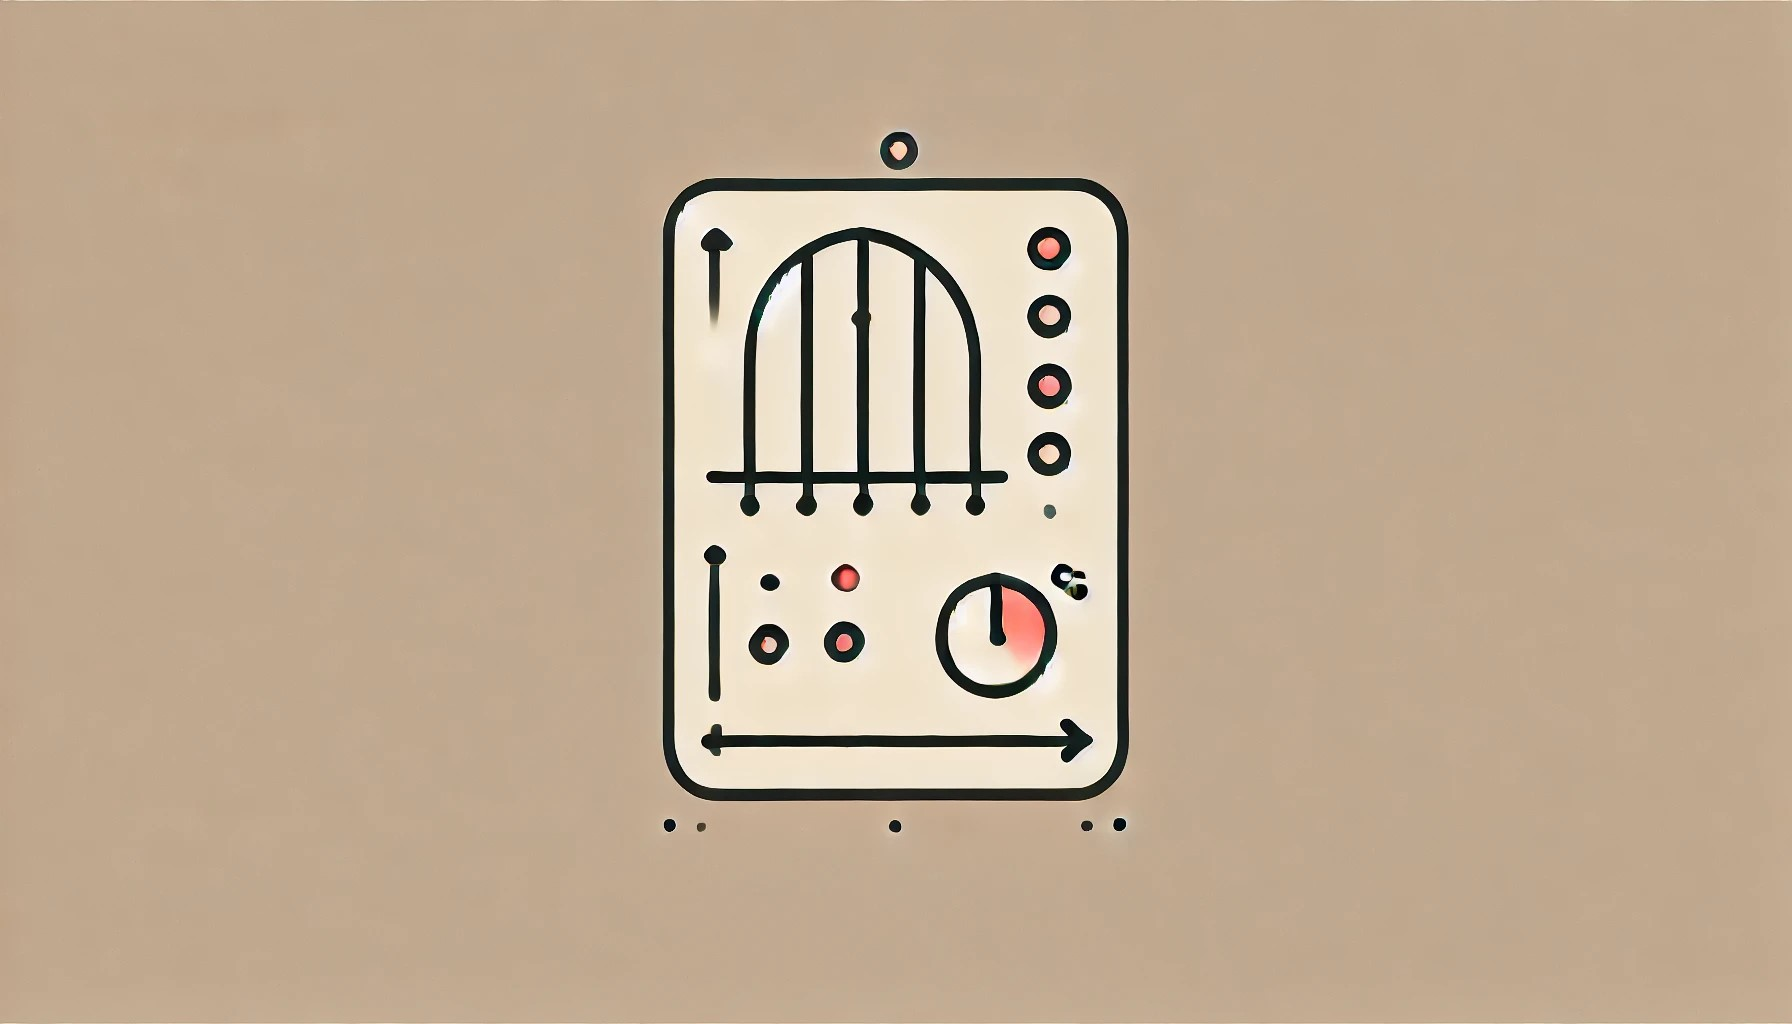

<a id="1"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34); background-color:rgb(255,255,255); "> <b> 1. Purpose🎉 </b></div>

**Use `Mann-kendall Test` to determine increasing or decreasing trends in time series data. I provide two methods: a publicly available library and a carefully explained formula from.**

<div style="background-color:#f0fae9; padding:6px 20px; border-radius:15px; font-size:20px">
    <br>
    <div style="font-weight:bold;font-size:24px;margin-left:8px;">💡Example</div>
    <div style="font-size:20px;margin-left:16px;">Alpahbet's stock price from 2006 to 2007.</div>
    <br>
    <div style="font-weight:bold;font-size:24px;margin-left:8px;">💡Direction</div>
    <ul style="font-size:20px;">
      <li>Using library: pymannkendall</li>
      <li>Explaining detailed mathematic</li>
    </ul>
</div>

<a id="2"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34); background-color:rgb(255,255,255); "> <b> 2. Preparation⚙️</b></div>

**Get stock data and library. I made the dataset of stock values of Alphabet and you can use it.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install pymannkendall
import pymannkendall as mk
import statsmodels.api as sm

In [2]:
## The path of the dataset 
path = '/kaggle/input/gafamfaang-and-matana-stock-values-economics/gafam_stock.pkl'

# Use numpy to load dictionary format
d_GAFAM = np.load(path, allow_pickle="TRUE")
Google = list(d_GAFAM.keys())[0]
df = d_GAFAM[Google]

# From 2006 to 2007
data = df[350:600]

Text(0, 0.5, 'Open value')

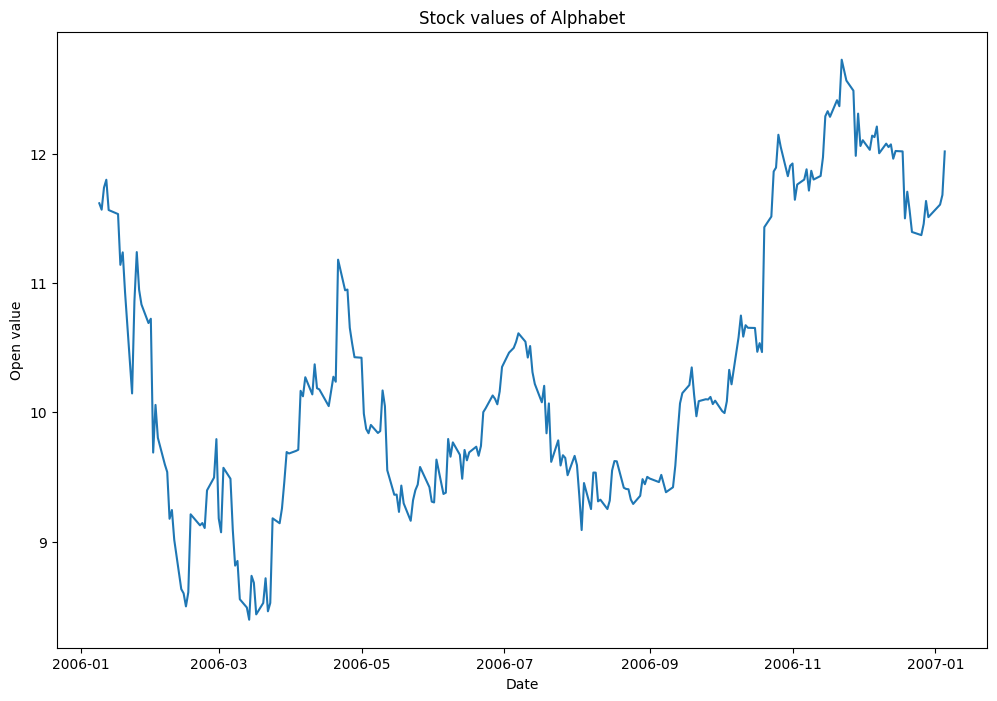

In [3]:
# This is the trend data I use from now
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(data.index, data.Open)
ax.set_title('Stock values of Alphabet')
ax.set_xlabel('Date')
ax.set_ylabel('Open value')

<a id="3"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34); background-color:rgb(255,255,255); "> <b> 3. Mann-Kendall Test🌟</b></div>

### You can get reference of `pymannkendall` [here](https://pypi.org/project/pymannkendall/)

Trend:  increasing
P-value:  0.0
Z-value:  8.79506893455565
Slope:  0.008866691589355468


Text(0, 0.5, 'Open value')

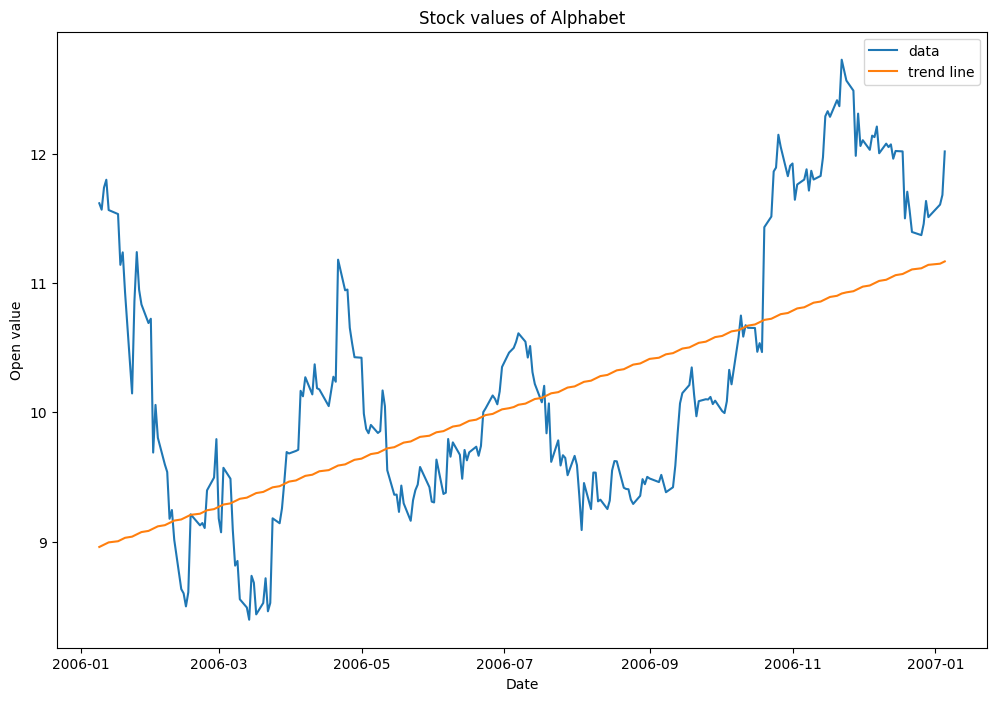

In [4]:
# Simply you can get test result
result = mk.original_test(data.Open)

print('Trend: ',result.trend)
print('P-value: ',result.p)
print('Z-value: ',result.z)
print('Slope: ',result.slope)

# Visualize the trend line
trend_line = np.arange(len(data.Open)) * result.slope + result.intercept
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(data.Open)
ax.plot(data.index, trend_line)
ax.legend(['data', 'trend line'])
ax.set_title('Stock values of Alphabet')
ax.set_xlabel('Date')
ax.set_ylabel('Open value')

**Test result also contained them:**
- trend: tells the trend (increasing, decreasing or no trend)
- h: True (if trend is present) or False (if the trend is absence)
- p: p-value of the significance test
- z: normalized test statistics
- Tau: Kendall Tau
- s: Mann-Kendal's score
- var_s: Variance S
- slope: Theil-Sen estimator/slope
- intercept: intercept of Kendall-Theil Robust Line, for seasonal test, full period cycle consider as unit time step

## Other Methods

**It has other modified Mann-Kendall test like below:**
- Original Mann-Kendall test (original_test): Original Mann-Kendall test is a nonparametric test, which does not consider serial correlation or seasonal effects.

- Hamed and Rao Modified MK Test (hamed_rao_modification_test): This modified MK test proposed by Hamed and Rao (1998) to address serial autocorrelation issues. They suggested a variance correction approach to improve trend analysis. User can consider first n significant lag by insert lag number in this function. By default, it considered all significant lags.

- Yue and Wang Modified MK Test (yue_wang_modification_test): This is also a variance correction method for considered serial autocorrelation proposed by Yue, S., & Wang, C. Y. (2004). User can also set their desired significant n lags for the calculation.

- Modified MK test using Pre-Whitening method (pre_whitening_modification_test): This test suggested by Yue and Wang (2002) to using Pre-Whitening the time series before the application of trend test.

- Modified MK test using Trend free Pre-Whitening method (trend_free_pre_whitening_modification_test): This test also proposed by Yue and Wang (2002) to remove trend component and then Pre-Whitening the time series before application of trend test.

- Multivariate MK Test (multivariate_test): This is an MK test for multiple parameters proposed by Hirsch (1982). He used this method for seasonal mk test, where he considered every month as a parameter.

- Seasonal MK Test (seasonal_test): For seasonal time series data, Hirsch, R.M., Slack, J.R. and Smith, R.A. (1982) proposed this test to calculate the seasonal trend.

- Regional MK Test (regional_test): Based onHirsch (1982) proposed seasonal mk test, Helsel, D.R. and Frans, L.M., (2006) suggest regional mk test to calculate the overall trend in a regional scale.

- Correlated Multivariate MK Test (correlated_multivariate_test): This multivariate mk test proposed by Hipel (1994) where the parameters are correlated.

- Correlated Seasonal MK Test (correlated_seasonal_test): This method proposed by Hipel (1994) used, when time series significantly correlated with the preceding one or more months/seasons.

- Partial MK Test (partial_test): In a real event, many factors are affecting the main studied response parameter, which can bias the trend results. To overcome this problem, Libiseller (2002) proposed this partial mk test. It required two parameters as input, where, one is response parameter and other is an independent parameter.

- Theil-Sen's Slope Estimator (sens_slope): This method proposed by Theil (1950) and Sen (1968) to estimate the magnitude of the monotonic trend. Intercept is calculate using Conover, W.J. (1980) method.

- Seasonal Theil-Sen's Slope Estimator (seasonal_sens_slope): This method proposed by Hipel (1994) to estimate the magnitude of the monotonic trend, when data has seasonal effects. Intercept is calculate using Conover, W.J. (1980) method.

Trend:  increasing
P-value:  0.028579973736528652
Z-value:  2.189232112549129
Slope:  0.008866691589355468


Text(0, 0.5, 'Open value')

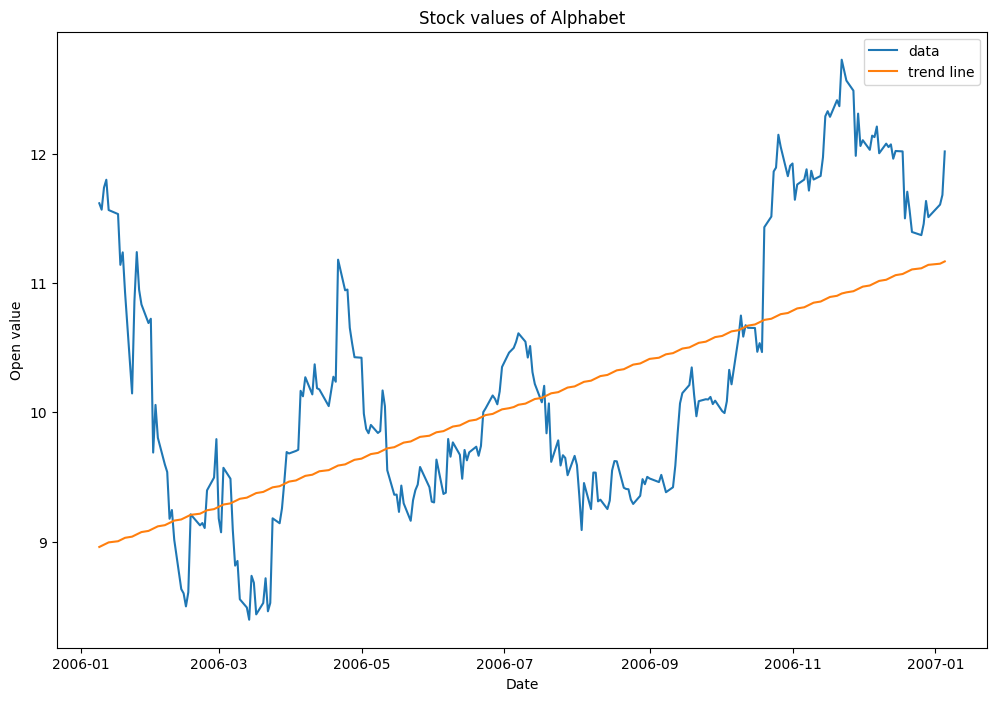

In [5]:
# Change the method
result = mk.hamed_rao_modification_test(data.Open)

print('Trend: ',result.trend)
print('P-value: ',result.p)
print('Z-value: ',result.z)
print('Slope: ',result.slope)

trend_line = np.arange(len(data.Open)) * result.slope + result.intercept
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(data.Open)
ax.plot(data.index, trend_line)
ax.legend(['data', 'trend line'])
ax.set_title('Stock values of Alphabet')
ax.set_xlabel('Date')
ax.set_ylabel('Open value')

<a id="4"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34); background-color:rgb(255,255,255); "> <b> 4. Detailed Mathematic🌟</b></div>

**With scipy, showing detailed steps of Mann-Kendall test****

In [6]:
import scipy as sp
def Mann_Kendall_test(x, alpha=0.05):
    x = x[~np.isnan(x)].reshape(-1)
    n = len(x)
    s = 0
    for k in range(n-1):
        for j in range(k+1, n):
            s += np.sign(x[j] - x[k])
    e = np.zeros(np.unique(x).shape)
    for i in range(len(np.unique(x))):
        e[i] = np.sum(np.unique(x)[i] == x)
    var_s = (n * (n - 1) * (2 * n + 5) + np.sum(e * (e - 1) * (2 * e + 5))) / 18
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s == 0:
        z = 0
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    # P-value
    p = 2 * (1 - sp.stats.norm.cdf(abs(z)))  # Two tail test
    h = abs(z) > sp.stats.norm.ppf(1 - alpha / 2)
    print('▼Mann-Kendall Test')
    print(' P-value: ', round(p,3))
    print(' Z-value ',z,round(5,3))
    if (z < 0) and h:
        print(' The null hypothesis is rejected.')
        print(' ->Decreasing')
        trend = 'Decreasing'
    elif (z > 0) and h:
        print(' The null hypothesis is rejected.')
        print('  ->Increasing')
        trend = 'Increasing'
    elif (z==0) and h:
        print(' The null hypothesis is rejected.')
        print('  ->No trends')
        trend = 'No trends'
    else:
        print(' The null hypothesis is not rejected.')
        print("  ->Can't conclude there is a trend.")
        trend = "Can't conclude there is a trend."
    return p, z, trend

In [7]:
p, z, trend = Mann_Kendall_test(np.array(data.Open))

▼Mann-Kendall Test
 P-value:  0.0
 Z-value  8.795063898611621 5
 The null hypothesis is rejected.
  ->Increasing
